In [1]:
import pandas as pd
import numpy as np
import sqlite3
db_path = "pair_trading.db"
conn = sqlite3.connect(db_path)
import pandas as pd

df = pd.read_sql(f"SELECT * FROM 'all_trades'", conn)
total_positive_trades = (df['pnl'] > 0).sum()
total_negative_trades = (df['pnl'] < 0).sum()
win_loss_ratio = total_positive_trades / total_negative_trades
win_loss_ratio

np.float64(1.315136476426799)

In [2]:
avg_pnl  = df['pnl'].mean()
sharpe = avg_pnl/df['pnl'].std(ddof=1)
sharpe

np.float64(0.34248162649988506)

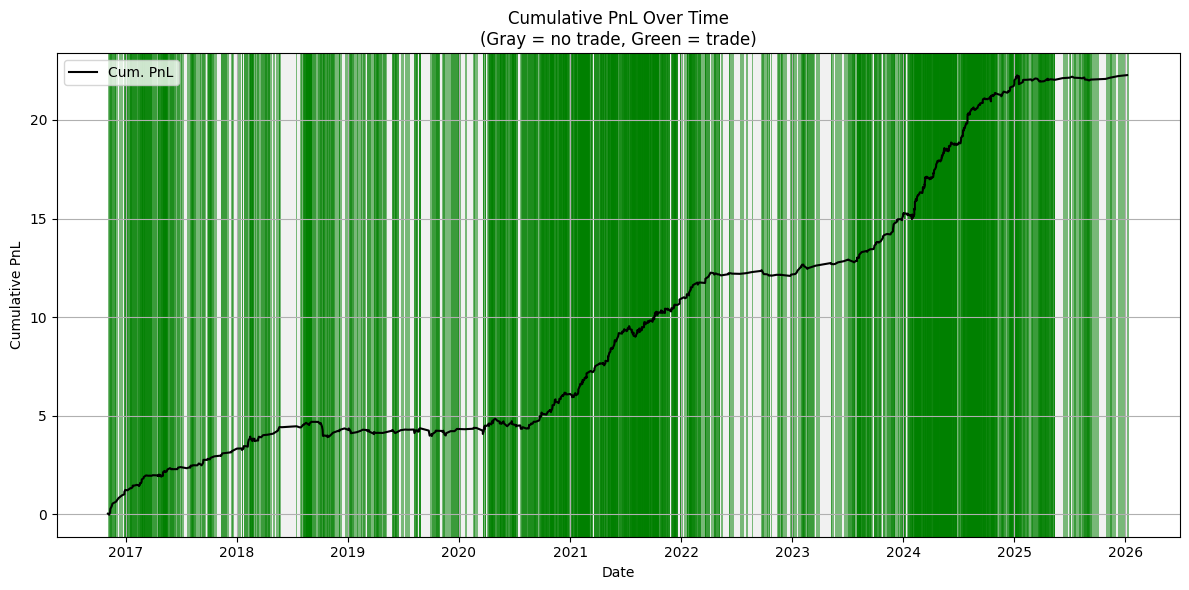

In [3]:
import matplotlib.pyplot as plt
df['start'] = pd.to_datetime(df['start'])
df = df.sort_values(by='start')
df['cumulative_pnl'] = df['pnl'].cumsum()
fig, ax = plt.subplots(figsize=(12,6))

# 2) plot your cumulative PnL
ax.plot(df['start'], df['cumulative_pnl'],
        color='black', linewidth=1.5, label='Cum. PnL')

# 3) shade the entire span light-gray
xmin, xmax = df['start'].min(), df['end'].max()
ax.axvspan(xmin, xmax, facecolor='lightgray', alpha=0.3)

# 4) overlay green spans for each trade
for s, e in zip(df['start'], df['end']):
    ax.axvspan(s, e, facecolor='green', alpha=0.5)

# 5) polish
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL')
ax.set_title('Cumulative PnL Over Time\n(Gray = no trade, Green = trade)')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Extract year into its own column
df['year'] = df['start'].dt.year

# Count rows per year
trades_per_year = df.groupby('year').size()

print(trades_per_year)

year
2016     14
2017     81
2018     66
2019     54
2020    101
2021    212
2022     55
2023     77
2024    227
2025     45
2026      1
dtype: int64


In [5]:
import datetime as dt
import yfinance as yf
start_date = dt.datetime.now() - dt.timedelta(days=365)
df = yf.download(
                    f"HCLTECH.NS",
                    start=start_date,
                    end=dt.datetime.now(),
                    auto_adjust=True
                )
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HCLTECH.NS,HCLTECH.NS,HCLTECH.NS,HCLTECH.NS,HCLTECH.NS
Date,,,,,
2025-01-13,1916.523560,1938.488271,1893.402737,1921.822081,5694121
2025-01-14,1747.115356,1867.969775,1731.894101,1865.175985,15819311
2025-01-15,1758.820312,1776.016520,1746.152122,1768.743047,3350594
2025-01-16,1726.595581,1770.621433,1719.900223,1765.852811,5362008
2025-01-17,1740.852295,1744.939440,1703.045784,1725.379326,2424374
...,...,...,...,...,...
2026-01-07,1647.699951,1654.500000,1616.699951,1620.800049,3816569
2026-01-08,1646.699951,1660.599976,1635.400024,1653.300049,3266398
